# Fake News Detection

In [5]:
import numpy as np
import pandas as pd
import plotly.express as px
from nltk.stem import PorterStemmer
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [6]:
true_news = pd.read_csv('/kaggle/input/datasets/mohamedahmed285/fake-and-news-data/True.csv')
fake_news = pd.read_csv('/kaggle/input/datasets/mohamedahmed285/fake-and-news-data/Fake.csv')

In [9]:
true_news

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [10]:
fake_news

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [14]:
true_df = pd.concat([true_news['title'],true_news['text'],true_news['subject'],true_news['date'],pd.Series(0,index = true_news.index, name='label')],axis = 1)
fake_df = pd.concat([fake_news['title'],fake_news['text'],fake_news['subject'],fake_news['date'],pd.Series(1,index = fake_news.index, name='label')],axis = 1)

In [15]:
fake_df

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",1
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",1
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",1
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",1


In [16]:
true_df

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",0
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",0
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",0
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",0


In [53]:
news_df = pd.concat([true_df,fake_df], axis=0).sample(frac=1.0,random_state =34).reset_index(drop=True)

In [54]:
news_df

,title,text,subject,date,label
0,SUNDAY SCREENING: ‘The War on Democracy’ (2007),"21st Century Wire says Each week, 21WIRE will ...",US_News,"August 13, 2017",1
1,SAY WHAT? Obama Gives Go Ahead For New UN “Reg...,"If seven years ago, someone told Americans tha...",left-news,"Nov 20, 2015",1
2,U.S. farm groups oppose Trump's cuts to agricu...,CHICAGO (Reuters) - U.S. farm groups on Tuesda...,politicsNews,"May 23, 2017",0
3,BREAKING: Federal Judge STOPS Obamacare Transg...,O Connor found that the plaintiffs had standin...,left-news,"Dec 31, 2016",1
4,OBAMA NOMINATES FIRST MUSLIM FOR FEDERAL BENCH...,President Obama is clearly not quite ready to ...,politics,"Sep 8, 2016",1
...,...,...,...,...,...
44893,Laura Bush Stuns Republican Party – Hinted Th...,It s no secret Republican women hate Donald Tr...,News,"April 10, 2016",1
44894,"Here’s How Much Trump Is Paying Omarosa, Kell...","The average American makes about $50,000 a yea...",News,"June 30, 2017",1
44895,REALLY FAKE NEWS: New York Times Finally Retra...,21st Century Wire says Back during the 2016 el...,US_News,"June 30, 2017",1
44896,WHOA! SENATOR TOM COTTON Blasts Harry Reid’s “...,Senator Tom Cotton is such a great representat...,Government News,"May 26, 2016",1


# Preprocessing

In [27]:
subject_analysis = pd.crosstab(news_df['subject'], news_df['label'], margins=True)
print(subject_analysis)

label                0      1    All
subject                             
Government News      0   1570   1570
Middle-east          0    778    778
News                 0   9050   9050
US_News              0    783    783
left-news            0   4459   4459
politics             0   6841   6841
politicsNews     11272      0  11272
worldnews        10145      0  10145
All              21417  23481  44898


In [28]:
print(news_df['date'].head(10))
print("\nNumber of unique dates:", news_df['date'].nunique())

0        August 13, 2017
1           Nov 20, 2015
2          May 23, 2017 
3           Dec 31, 2016
4            Sep 8, 2016
5    September 30, 2017 
6     December 22, 2017 
7          May 27, 2017 
8      October 26, 2017 
9     December 17, 2017 
Name: date, dtype: object

Number of unique dates: 2397


In [29]:
empty_text = news_df[news_df['text'].str.isspace() | (news_df['text'] == '')]
print(f"Rows with empty text: {len(empty_text)}")

Rows with empty text: 631


In [32]:
news_df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [ ]:
news_df['content'] = news_df['title'] + " " + news_df['text']

news_df = news_df.drop(['title', 'text', 'subject', 'date'], axis=1)

print(news_df.head())

In [76]:
ps = PorterStemmer()
def process_content(content):
    new_content = content.lower()
    new_content = re.sub(r'\$[^\s]+','dollar' , new_content)
    new_content = re.sub(r'[^a-z0-9\s]','', new_content)
    new_content = re.sub(r'[0-9]+','number', new_content)
    new_content = new_content.split()
    new_content = list(map(lambda x: ps.stem(x), new_content))
    return ' '.join(new_content)

1. **Lowercasing:** Converts all text to lowercase to ensure case uniformity (so "President" and "president" are treated as the same word).
2. **Currency Generalization:** Uses the regex `r'\$[^\s]+'` to find any monetary value (e.g., `$100`, `$5.5M`) and replaces it with the generic string `'dollar'`. 
3. **Punctuation Stripping:** Uses the regex `r'[^a-z0-9\s]'` to remove all special characters, commas, and periods, leaving behind only alphanumeric characters and spaces.
4. **Number Generalization:** Uses the regex `r'[0-9]+'` to identify remaining sequences of digits and replaces them with the string `'number'`. This prevents the model from overfitting to highly specific dates or statistics.
5. **Tokenization:** Uses `.split()` to break the cleaned, continuous string into a list of individual words.
6. **Stemming:** Applies the **PorterStemmer** to the list of words, trimming words down to their root morphological form (e.g., reducing "running", "runs", and "ran" down to their base meaning).
7. **Recombination:** Joins the stemmed tokens back into a single, space-separated string, formatting it perfectly for Scikit-Learn's Vectorizers.

In [77]:
news_df['content'] = news_df['content'].apply(process_content)

In [79]:
news_df

,label,content
0,1,sunday screen the war on democraci number numb...
1,1,say what obama give go ahead for new un region...
2,0,us farm group oppos trump cut to agricultur sp...
3,1,break feder judg stop obamacar transgend abort...
4,1,obama nomin first muslim for feder bench can a...
...,...,...
44893,1,laura bush stun republican parti hint that she...
44894,1,here how much trump is pay omarosa kellyann co...
44895,1,realli fake news new york time final retract i...
44896,1,whoa senat tom cotton blast harri reid cancer ...


Exact count of each class:
label
1    23481
0    21417
Name: count, dtype: int64


/tmp/ipykernel_55/1920130283.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=news_df, palette='viridis')


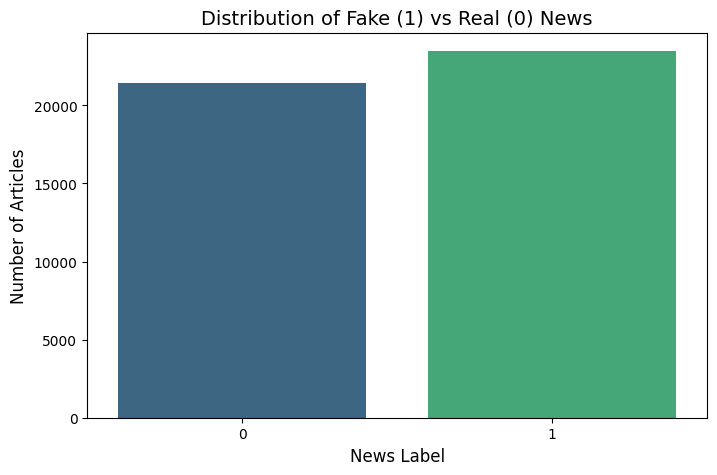

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Exact count of each class:")
print(news_df['label'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=news_df, palette='viridis')

plt.title('Distribution of Fake (1) vs Real (0) News', fontsize=14)
plt.xlabel('News Label', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)

plt.show()

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

X = news_df['content']
y = news_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bag of Words branch a
bow_vectorizer = CountVectorizer(max_features=5000, stop_words='english') 
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# TF-IDF branch b
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

**Branch A: Bag of Words (BoW)**
* `X_train_bow`: The training features
* `X_test_bow`: The testing features (only transformed, no leakage)

**Branch B: TF-IDF**
* `X_train_tfidf`: The training features
* `X_test_tfidf`: The testing features (only transformed, no leakage)

**Labels**
* `y_train`: Training labels (1 = Fake, 0 = Real)
* `y_test`: Testing labels

# Train